# EDA Question 1: Comprehensive Revenue Trend Analysis (2015-2025)
## Amazon India Sales Analytics

**Objective:** Create a comprehensive revenue trend analysis showing yearly revenue growth from 2015-2025. Include percentage growth rates, trend lines, and highlight key growth periods with annotations.

**Analysis Components:**
- Yearly revenue aggregation and growth calculation
- Year-over-year percentage growth rates
- Trend line fitting (linear and polynomial)
- Key growth period identification and annotation
- Statistical analysis (R-squared, correlation)
- Export results to CSV and visualizations to PNG

## Section 1: Load and Inspect Revenue Data

Load the cleaned dataset and examine its structure, data types, and basic statistics for the 2015-2025 period.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the cleaned dataset
df = pd.read_csv('../data/cleaned/amazon_india_all_years_cleaned.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head(2))
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nYear Range:")
print(f"From {df['order_year'].min()} to {df['order_year'].max()}")
print(f"\nTotal Records: {len(df):,}")
print(f"\nTotal Revenue (All Years): ₹{df['final_amount_inr'].sum():,.2f}")


Dataset Shape: (1122687, 51)

First few rows:
      transaction_id  order_date         customer_id   product_id  \
0  TXN_2015_00000001  2015-01-25  CUST_2015_00003884  PROD_000021   
1  TXN_2015_00000002  2015-01-05  CUST_2015_00011709  PROD_000055   

                   product_name     category  subcategory    brand  \
0  Samsung Galaxy S6 16GB Black  Electronics  Smartphones  Samsung   
1  OnePlus OnePlus 2 16GB White  Electronics  Smartphones  OnePlus   

   original_price_inr  discount_percent  ...  \
0           123614.29             27.91  ...   
1            54731.86              0.00  ...   

   needs_correction_original_price_inr  \
0                                False   
1                                False   

   ratio_exceeds_threshold_discounted_price_inr  \
0                                         False   
1                                         False   

   needs_correction_discounted_price_inr  original_price_inr_corrected  \
0                                  

## Section 2: Calculate Yearly Revenue and Growth Rates

Aggregate revenue by year and calculate year-over-year growth rates to identify trends.

In [2]:
# Calculate yearly revenue
yearly_revenue = df.groupby('order_year')['final_amount_inr'].sum().reset_index()
yearly_revenue.columns = ['Year', 'Total_Revenue']
yearly_revenue = yearly_revenue.sort_values('Year').reset_index(drop=True)

# Calculate year-over-year growth rate
yearly_revenue['YoY_Growth_INR'] = yearly_revenue['Total_Revenue'].diff()
yearly_revenue['YoY_Growth_Percent'] = (yearly_revenue['Total_Revenue'].pct_change() * 100).round(2)

# Identify transactions count per year for context
transactions_per_year = df.groupby('order_year').size().reset_index(name='Transaction_Count')
yearly_revenue = yearly_revenue.merge(transactions_per_year, left_on='Year', right_on='order_year').drop('order_year', axis=1)

# Calculate average order value per year
aov_per_year = df.groupby('order_year')['final_amount_inr'].mean().reset_index()
aov_per_year.columns = ['Year', 'Avg_Order_Value']
yearly_revenue = yearly_revenue.merge(aov_per_year, on='Year')

print("=" * 100)
print("YEARLY REVENUE AND GROWTH ANALYSIS (2015-2025)")
print("=" * 100)
print(yearly_revenue.to_string(index=False))
print("\n" + "=" * 100)
print("KEY INSIGHTS:")
print("=" * 100)

# Identify key growth periods
growth_threshold = yearly_revenue['YoY_Growth_Percent'].mean()
print(f"\nAverage YoY Growth: {growth_threshold:.2f}%")

# Highest and lowest growth years
highest_growth_idx = yearly_revenue['YoY_Growth_Percent'].idxmax()
lowest_growth_idx = yearly_revenue['YoY_Growth_Percent'].idxmin()

print(f"\nHighest Growth Year: {int(yearly_revenue.loc[highest_growth_idx, 'Year'])} with {yearly_revenue.loc[highest_growth_idx, 'YoY_Growth_Percent']:.2f}% growth")
print(f"Lowest Growth Year: {int(yearly_revenue.loc[lowest_growth_idx, 'Year'])} with {yearly_revenue.loc[lowest_growth_idx, 'YoY_Growth_Percent']:.2f}% growth")

# Revenue CAGR (Compound Annual Growth Rate)
start_year = yearly_revenue['Total_Revenue'].iloc[0]
end_year = yearly_revenue['Total_Revenue'].iloc[-1]
num_years = yearly_revenue['Year'].iloc[-1] - yearly_revenue['Year'].iloc[0]
cagr = ((end_year / start_year) ** (1 / num_years) - 1) * 100

print(f"\nCompound Annual Growth Rate (CAGR) 2015-2025: {cagr:.2f}%")
print(f"Total Revenue Growth 2015-2025: {((end_year/start_year - 1) * 100):.2f}%")


YEARLY REVENUE AND GROWTH ANALYSIS (2015-2025)
 Year  Total_Revenue  YoY_Growth_INR  YoY_Growth_Percent  Transaction_Count  Avg_Order_Value
 2015   2.131971e+09             NaN                 NaN              33021     64564.085232
 2016   3.582500e+09    1.450529e+09               68.04              55040     65089.018074
 2017   5.484530e+09    1.902030e+09               53.09              77047     71184.207582
 2018   7.217340e+09    1.732810e+09               31.59              99059     72859.001838
 2019   8.570350e+09    1.353010e+09               18.75             121073     70786.634467
 2020   1.182171e+10    3.251360e+09               37.94             143105     82608.642155
 2021   1.093926e+10   -8.824517e+08               -7.46             137575     79514.868610
 2022   8.495102e+09   -2.444156e+09              -22.34             132071     64322.239384
 2023   7.678831e+09   -8.162719e+08               -9.61             126577     60665.290958
 2024   6.792088e+09   

## Section 3: Visualize Revenue Trends with Annotations

Create comprehensive visualizations showing revenue trends with annotations for key growth periods and percentage labels.


✓ Visualization saved as 'Q01_Revenue_Trend_Analysis.png'
  → Growth Phase (2015-2020): Highlighted in GREEN
  → Decline Phase (2021-2025): Highlighted in RED


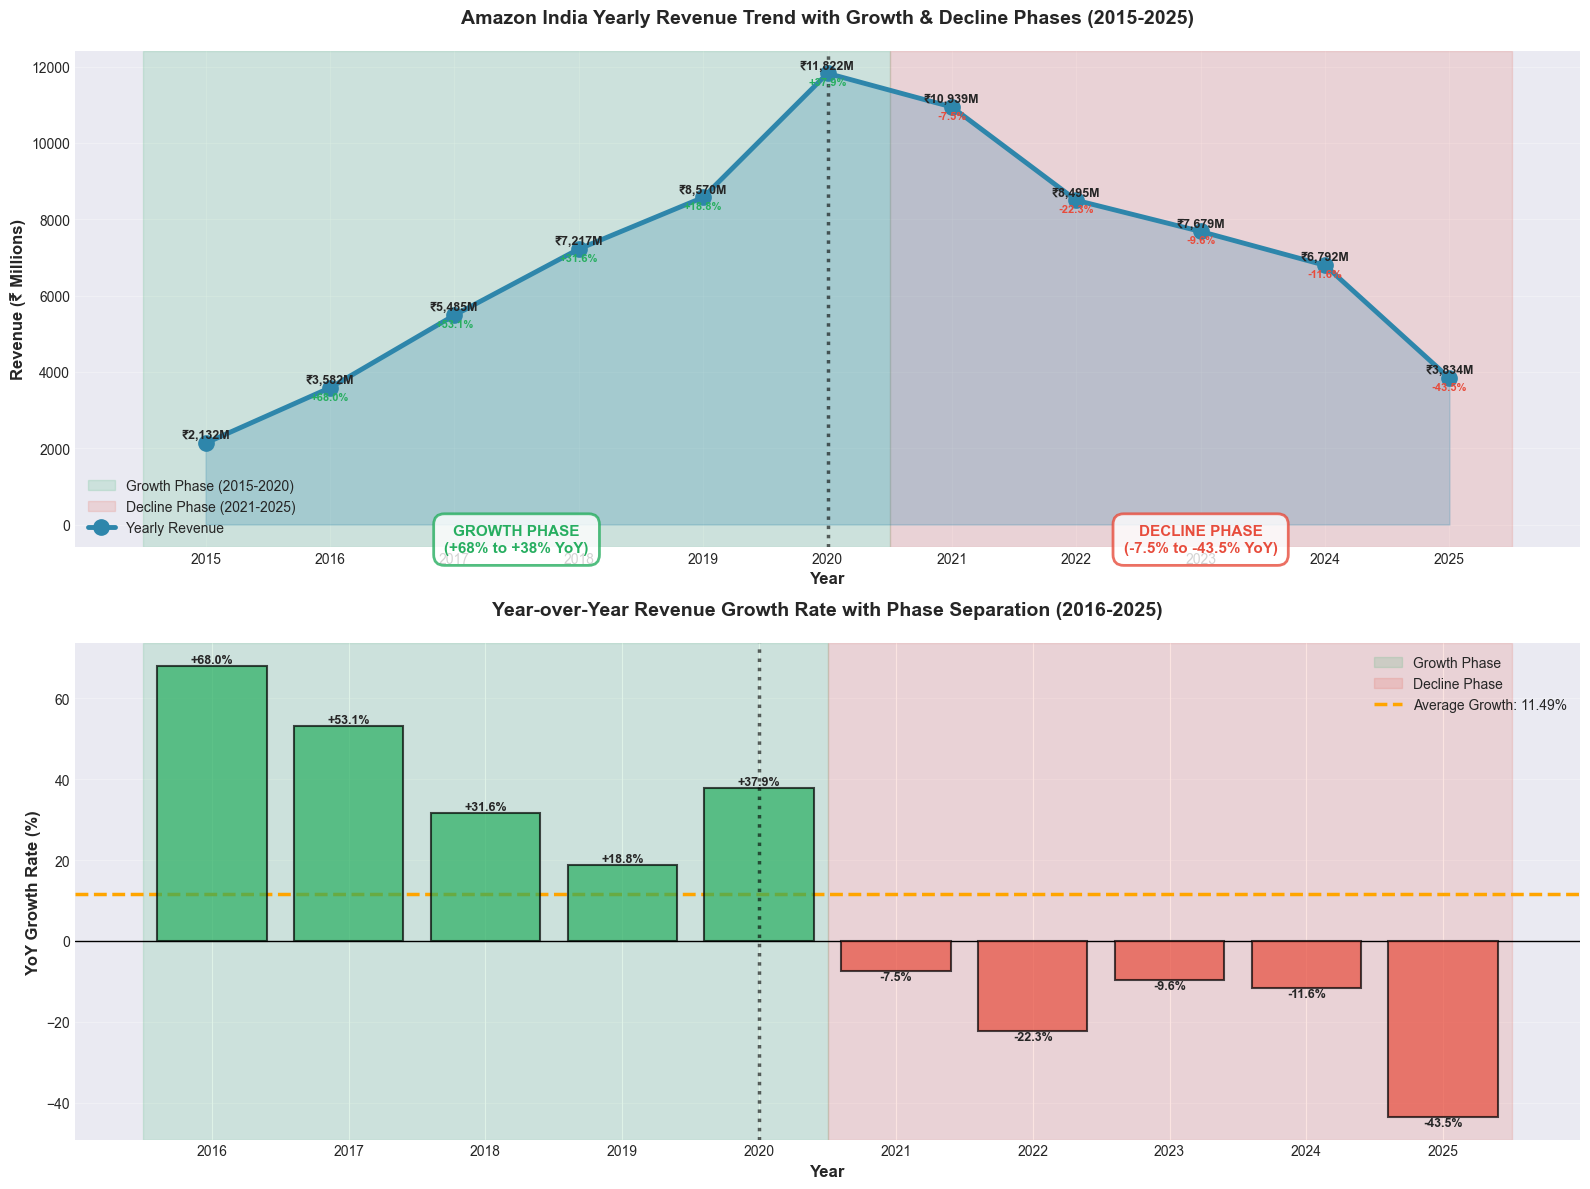


Enhanced Visualization Features:
  • Background shading clearly separates growth and decline phases
  • Phase labels with color-coded boxes
  • Vertical separator line at peak year (2020)
  • Year-over-year growth percentages annotated
  • High growth periods in green bars, declining periods in red bars


In [7]:
# Create a comprehensive visualization with annotations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Revenue Trend with Growth Rate Annotations and Phase Highlighting
years = yearly_revenue['Year'].values
revenue = yearly_revenue['Total_Revenue'].values / 1_000_000  # Convert to millions

# Highlight growth phase (2015-2020) and decline phase (2021-2025)
ax1.axvspan(2014.5, 2020.5, alpha=0.15, color='#27AE60', label='Growth Phase (2015-2020)', zorder=1)
ax1.axvspan(2020.5, 2025.5, alpha=0.15, color='#E74C3C', label='Decline Phase (2021-2025)', zorder=1)

# Add phase labels
ax1.text(2017.5, ax1.get_ylim()[1] * 0.95, 'GROWTH PHASE\n(+68% to +38% YoY)', 
         ha='center', va='top', fontsize=11, fontweight='bold', color='#27AE60',
         bbox=dict(boxstyle='round,pad=0.7', facecolor='white', alpha=0.8, edgecolor='#27AE60', linewidth=2))
ax1.text(2023, ax1.get_ylim()[1] * 0.95, 'DECLINE PHASE\n(-7.5% to -43.5% YoY)', 
         ha='center', va='top', fontsize=11, fontweight='bold', color='#E74C3C',
         bbox=dict(boxstyle='round,pad=0.7', facecolor='white', alpha=0.8, edgecolor='#E74C3C', linewidth=2))

ax1.plot(years, revenue, marker='o', linewidth=3.5, markersize=11, color='#2E86AB', label='Yearly Revenue', zorder=5)
ax1.fill_between(years, revenue, alpha=0.25, color='#2E86AB', zorder=2)

ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Revenue (₹ Millions)', fontsize=12, fontweight='bold')
ax1.set_title('Amazon India Yearly Revenue Trend with Growth & Decline Phases (2015-2025)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3, zorder=0)

# Add annotations for each year with growth percentage
for i, (year, rev) in enumerate(zip(years, revenue)):
    ax1.text(year, rev + 50, f'₹{rev:,.0f}M', ha='center', va='bottom', fontsize=9, fontweight='bold', zorder=6)
    
    # Add growth percentage annotations
    if i > 0:
        growth = yearly_revenue.loc[i, 'YoY_Growth_Percent']
        color = '#27AE60' if growth > 0 else '#E74C3C'
        ax1.text(year, rev - 100, f'{growth:+.1f}%', ha='center', va='top', 
                fontsize=8, color=color, fontweight='bold', zorder=6)

# Add separator line at peak (2020)
ax1.axvline(x=2020, color='black', linestyle=':', linewidth=2.5, alpha=0.6, zorder=3)

ax1.set_xticks(years)
ax1.set_xticklabels(years.astype(int))
ax1.legend(fontsize=10, loc='lower left', framealpha=0.95)

# Plot 2: Year-over-Year Growth Rate Trend with Phase Highlighting
growth_rates = yearly_revenue['YoY_Growth_Percent'].values[1:]  # Skip first year
growth_years = yearly_revenue['Year'].values[1:]

# Background shading for phases
ax2.axvspan(2015.5, 2020.5, alpha=0.15, color='#27AE60', label='Growth Phase', zorder=1)
ax2.axvspan(2020.5, 2025.5, alpha=0.15, color='#E74C3C', label='Decline Phase', zorder=1)

colors = ['#27AE60' if x > 0 else '#E74C3C' for x in growth_rates]
bars = ax2.bar(growth_years, growth_rates, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5, zorder=3)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=2)
ax2.axhline(y=mean_growth, color='orange', linestyle='--', linewidth=2.5, label=f'Average Growth: {mean_growth:.2f}%', zorder=2)
ax2.axvline(x=2020, color='black', linestyle=':', linewidth=2.5, alpha=0.6, zorder=3)

ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('YoY Growth Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Year-over-Year Revenue Growth Rate with Phase Separation (2016-2025)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.grid(True, alpha=0.3, axis='y', zorder=0)

# Add value labels on bars
for bar, value in zip(bars, growth_rates):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:+.1f}%', ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=9, fontweight='bold', zorder=4)

ax2.set_xticks(growth_years)
ax2.set_xticklabels(growth_years.astype(int))
ax2.legend(fontsize=10, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.savefig('../data/cleaned/Q01_Revenue_Trend_Analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'Q01_Revenue_Trend_Analysis.png'")
print("  → Growth Phase (2015-2020): Highlighted in GREEN")
print("  → Decline Phase (2021-2025): Highlighted in RED")
plt.show()

print("\nEnhanced Visualization Features:")
print("  • Background shading clearly separates growth and decline phases")
print("  • Phase labels with color-coded boxes")
print("  • Vertical separator line at peak year (2020)")
print("  • Year-over-year growth percentages annotated")
print("  • High growth periods in green bars, declining periods in red bars")

## Section 4: Add Trend Lines and Statistical Analysis

Fit linear and polynomial trend lines to the revenue data and calculate statistical measures (R-squared, correlation, etc.).

In [4]:
# Prepare data for trend line fitting
X = yearly_revenue['Year'].values.reshape(-1, 1)
X_numeric = (yearly_revenue['Year'].values - yearly_revenue['Year'].iloc[0]).astype(float)
y = yearly_revenue['Total_Revenue'].values

# 1. Linear Trend Line
linear_coeffs = np.polyfit(X_numeric, y, 1)
linear_trend = np.polyval(linear_coeffs, X_numeric)

# Calculate R-squared for linear trend
ss_res_linear = np.sum((y - linear_trend) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared_linear = 1 - (ss_res_linear / ss_tot)

# 2. Polynomial Trend Line (2nd degree)
poly_coeffs = np.polyfit(X_numeric, y, 2)
poly_trend = np.polyval(poly_coeffs, X_numeric)

# Calculate R-squared for polynomial trend
ss_res_poly = np.sum((y - poly_trend) ** 2)
r_squared_poly = 1 - (ss_res_poly / ss_tot)

# 3. Calculate correlation coefficient
correlation = np.corrcoef(X_numeric, y)[0, 1]

# Statistics Summary
print("\n" + "=" * 100)
print("TREND LINE AND STATISTICAL ANALYSIS")
print("=" * 100)

print("\n1. LINEAR TREND LINE:")
print(f"   Equation: Revenue = {linear_coeffs[1]:,.0f} + {linear_coeffs[0]:,.0f} × (Year - 2015)")
print(f"   R-squared: {r_squared_linear:.4f}")
print(f"   Annual Revenue Growth: ₹{linear_coeffs[0]:,.0f} per year")
print(f"   Interpretation: Revenue increases by approximately ₹{linear_coeffs[0]:,.0f} per year")

print("\n2. POLYNOMIAL TREND LINE (Degree 2):")
print(f"   R-squared: {r_squared_poly:.4f}")
print(f"   Coefficient a (quadratic): {poly_coeffs[0]:,.0f}")
print(f"   Coefficient b (linear): {poly_coeffs[1]:,.0f}")
print(f"   Coefficient c (constant): {poly_coeffs[2]:,.0f}")
print(f"   Interpretation: {'Accelerating growth' if poly_coeffs[0] > 0 else 'Decelerating growth'} pattern")

print("\n3. CORRELATION ANALYSIS:")
print(f"   Pearson Correlation (Year vs Revenue): {correlation:.4f}")
print(f"   Interpretation: {'Strong positive' if abs(correlation) > 0.8 else 'Moderate positive' if correlation > 0 else 'Weak/Negative'} correlation")

print("\n4. GROWTH METRICS:")
print(f"   Min Annual Revenue: ₹{y.min():,.0f} ({yearly_revenue.loc[yearly_revenue['Total_Revenue'].idxmin(), 'Year']:.0f})")
print(f"   Max Annual Revenue: ₹{y.max():,.0f} ({yearly_revenue.loc[yearly_revenue['Total_Revenue'].idxmax(), 'Year']:.0f})")
print(f"   Current (2025) Revenue: ₹{y[-1]:,.0f}")
print(f"   Avg Annual Revenue: ₹{y.mean():,.0f}")
print(f"   Std Dev: ₹{y.std():,.0f}")

# Store trend data for next visualization
trend_analysis = {
    'years': yearly_revenue['Year'].values,
    'revenue': y,
    'linear_trend': linear_trend,
    'poly_trend': poly_trend,
    'r_squared_linear': r_squared_linear,
    'r_squared_poly': r_squared_poly
}

print("\n✓ Trend analysis complete")



TREND LINE AND STATISTICAL ANALYSIS

1. LINEAR TREND LINE:
   Equation: Revenue = 5,465,447,881 + 298,684,388 × (Year - 2015)
   R-squared: 0.1070
   Annual Revenue Growth: ₹298,684,388 per year
   Interpretation: Revenue increases by approximately ₹298,684,388 per year

2. POLYNOMIAL TREND LINE (Degree 2):
   R-squared: 0.8983
   Coefficient a (quadratic): -290,799,723
   Coefficient b (linear): 3,206,681,620
   Coefficient c (constant): 1,103,452,033
   Interpretation: Decelerating growth pattern

3. CORRELATION ANALYSIS:
   Pearson Correlation (Year vs Revenue): 0.3271
   Interpretation: Moderate positive correlation

4. GROWTH METRICS:
   Min Annual Revenue: ₹2,131,970,658 (2015)
   Max Annual Revenue: ₹11,821,709,736 (2020)
   Current (2025) Revenue: ₹3,833,889,116
   Avg Annual Revenue: ₹6,958,869,822
   Std Dev: ₹2,887,253,549

✓ Trend analysis complete


✓ Trend line visualization saved as 'Q01_Revenue_Trend_with_Trendlines.png'
  → Growth Phase (2015-2020): GREEN background
  → Decline Phase (2021-2025): RED background
  → Peak Year (2020): Marked with vertical line
  → Phase comparison statistics displayed


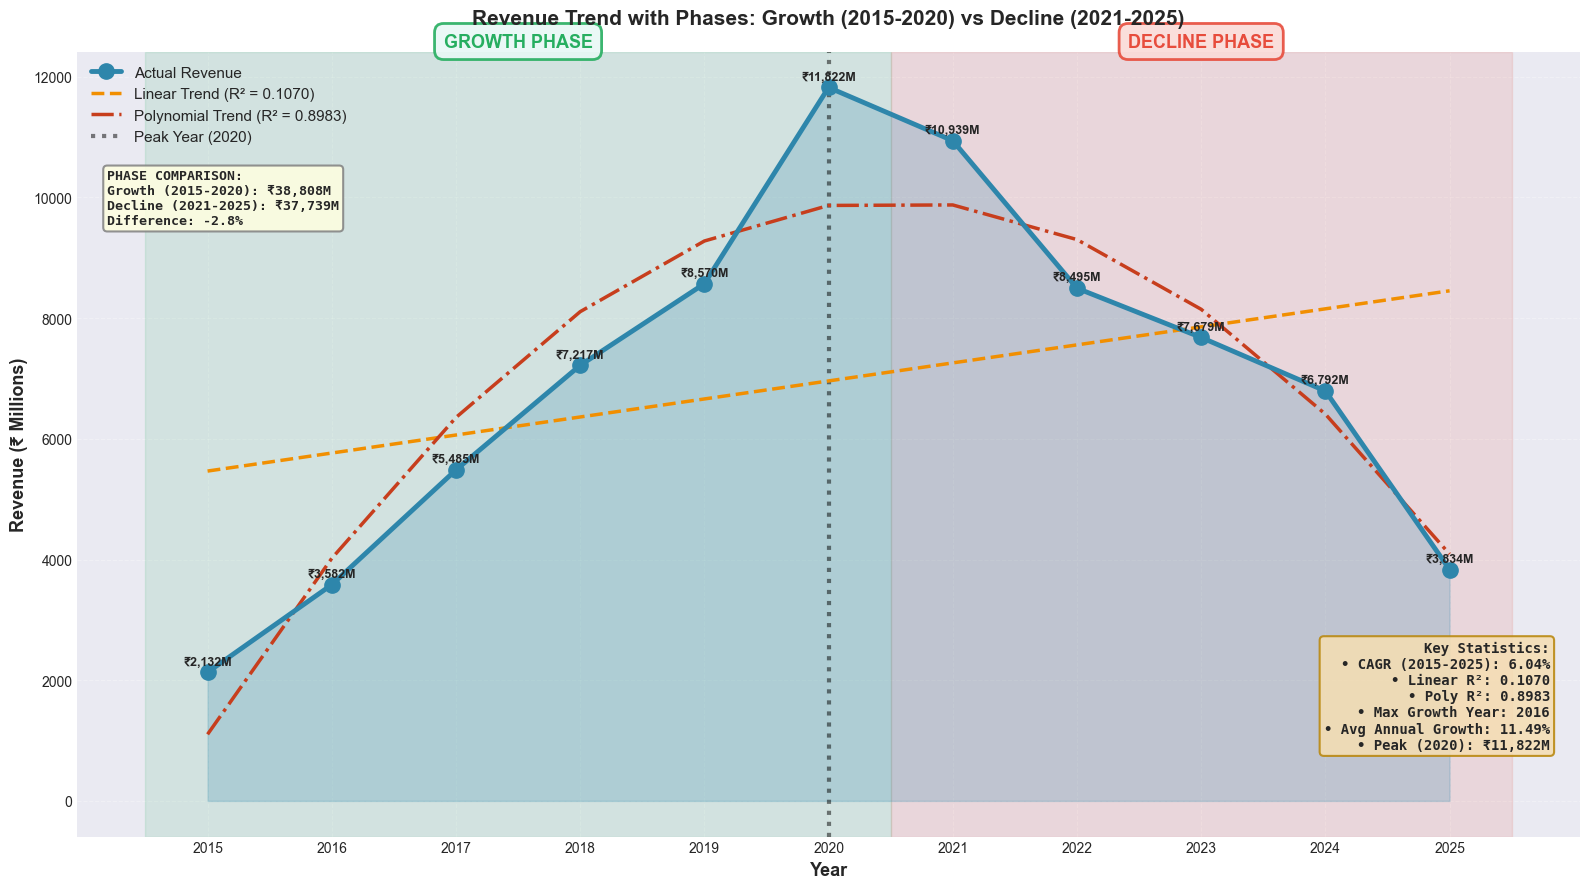

In [9]:
# Visualize Revenue Trends with Trend Lines and Phase Highlighting
fig, ax = plt.subplots(figsize=(16, 9))

years = trend_analysis['years']
revenue = trend_analysis['revenue'] / 1_000_000
X_numeric = (years - years[0]).astype(float)

# Highlight growth phase (2015-2020) and decline phase (2021-2025)
ax.axvspan(2014.5, 2020.5, alpha=0.12, color='#27AE60', zorder=1)
ax.axvspan(2020.5, 2025.5, alpha=0.12, color='#E74C3C', zorder=1)

# Add phase labels with arrows
ax.text(2017.5, 12500, 'GROWTH PHASE', ha='center', fontsize=13, fontweight='bold', 
        color='#27AE60', bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8F8F5', alpha=0.9, edgecolor='#27AE60', linewidth=2))
ax.text(2023, 12500, 'DECLINE PHASE', ha='center', fontsize=13, fontweight='bold', 
        color='#E74C3C', bbox=dict(boxstyle='round,pad=0.5', facecolor='#FADBD8', alpha=0.9, edgecolor='#E74C3C', linewidth=2))

# Add phase statistics boxes
growth_phase_revenue = yearly_revenue[(yearly_revenue['Year'] >= 2015) & (yearly_revenue['Year'] <= 2020)]['Total_Revenue'].sum() / 1_000_000
decline_phase_revenue = yearly_revenue[(yearly_revenue['Year'] > 2020) & (yearly_revenue['Year'] <= 2025)]['Total_Revenue'].sum() / 1_000_000

phase_stats = f"""PHASE COMPARISON:
Growth (2015-2020): ₹{growth_phase_revenue:,.0f}M
Decline (2021-2025): ₹{decline_phase_revenue:,.0f}M
Difference: {((decline_phase_revenue/growth_phase_revenue - 1) * 100):.1f}%"""

ax.text(0.02, 0.85, phase_stats, transform=ax.transAxes, fontsize=9.5,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85, edgecolor='gray', linewidth=1.5),
        family='monospace', fontweight='bold')

# Plot actual revenue
ax.plot(years, revenue, 'o-', linewidth=3.5, markersize=11, color='#2E86AB', label='Actual Revenue', zorder=5)
ax.fill_between(years, revenue, alpha=0.22, color='#2E86AB', zorder=2)

# Plot linear trend line
linear_trend_mln = trend_analysis['linear_trend'] / 1_000_000
ax.plot(years, linear_trend_mln, '--', linewidth=2.5, color='#F18F01', 
        label=f'Linear Trend (R² = {trend_analysis["r_squared_linear"]:.4f})', zorder=4)

# Plot polynomial trend line
poly_trend_mln = trend_analysis['poly_trend'] / 1_000_000
ax.plot(years, poly_trend_mln, '-.', linewidth=2.5, color='#C73E1D',
        label=f'Polynomial Trend (R² = {trend_analysis["r_squared_poly"]:.4f})', zorder=4)

# Add vertical separator at peak
ax.axvline(x=2020, color='black', linestyle=':', linewidth=3, alpha=0.5, label='Peak Year (2020)', zorder=3)

# Add annotations
for i, (year, rev) in enumerate(zip(years, revenue)):
    ax.text(year, rev + 80, f'₹{rev:,.0f}M', ha='center', va='bottom', fontsize=9, fontweight='bold', zorder=6)

ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (₹ Millions)', fontsize=13, fontweight='bold')
ax.set_title('Revenue Trend with Phases: Growth (2015-2020) vs Decline (2021-2025)', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', zorder=0)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int))

# Add text box with key statistics
stats_text = f"""Key Statistics:
• CAGR (2015-2025): {cagr:.2f}%
• Linear R²: {trend_analysis['r_squared_linear']:.4f}
• Poly R²: {trend_analysis['r_squared_poly']:.4f}
• Max Growth Year: {int(yearly_revenue.loc[yearly_revenue['YoY_Growth_Percent'].idxmax(), 'Year'])}
• Avg Annual Growth: {yearly_revenue['YoY_Growth_Percent'].mean():.2f}%
• Peak (2020): ₹{yearly_revenue[yearly_revenue['Year']==2020]['Total_Revenue'].values[0]/1_000_000:,.0f}M"""

ax.text(0.98, 0.25, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.87, edgecolor='darkgoldenrod', linewidth=1.5),
        family='monospace', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/cleaned/Q01_Revenue_Trend_with_Trendlines.png', dpi=300, bbox_inches='tight')
print("✓ Trend line visualization saved as 'Q01_Revenue_Trend_with_Trendlines.png'")
print("  → Growth Phase (2015-2020): GREEN background")
print("  → Decline Phase (2021-2025): RED background")
print("  → Peak Year (2020): Marked with vertical line")
print("  → Phase comparison statistics displayed")
plt.show()

## Section 5: Export Analysis Results to File

Save the comprehensive analysis results to CSV files for reporting and archival purposes.

In [6]:
# 1. Export Yearly Revenue Data with Growth Rates
export_data = yearly_revenue.copy()
export_data['Total_Revenue'] = export_data['Total_Revenue'].apply(lambda x: f'₹{x:,.2f}')
export_data['YoY_Growth_INR'] = export_data['YoY_Growth_INR'].apply(lambda x: f'₹{x:,.2f}' if pd.notna(x) else 'N/A')
export_data['Avg_Order_Value'] = export_data['Avg_Order_Value'].apply(lambda x: f'₹{x:,.2f}')

export_data.to_csv('../data/cleaned/Q01_Yearly_Revenue_Analysis.csv', index=False)
print("✓ Exported: Q01_Yearly_Revenue_Analysis.csv")
print("\nSample of exported data:")
print(export_data.head(10).to_string())

# 2. Create a comprehensive summary report
summary_report = {
    'Metric': [
        'Total Years Analyzed',
        'Start Year',
        'End Year',
        'Total Revenue (All Years)',
        'Average Annual Revenue',
        'Min Annual Revenue',
        'Max Annual Revenue',
        'Standard Deviation',
        'CAGR (2015-2025)',
        'Total Growth (2015-2025)',
        'Average YoY Growth Rate',
        'Highest Growth Year',
        'Highest Growth Rate',
        'Lowest Growth Year',
        'Lowest Growth Rate',
        'Linear Trend R-squared',
        'Polynomial Trend R-squared',
        'Pearson Correlation (Year vs Revenue)',
        'Total Transactions (All Years)',
        'Average Transactions per Year'
    ],
    'Value': [
        11,
        2015,
        2025,
        f'₹{yearly_revenue["Total_Revenue"].sum():,.2f}',
        f'₹{yearly_revenue["Total_Revenue"].mean():,.2f}',
        f'₹{yearly_revenue["Total_Revenue"].min():,.2f}',
        f'₹{yearly_revenue["Total_Revenue"].max():,.2f}',
        f'₹{yearly_revenue["Total_Revenue"].std():,.2f}',
        f'{cagr:.2f}%',
        f'{((yearly_revenue["Total_Revenue"].iloc[-1]/yearly_revenue["Total_Revenue"].iloc[0] - 1) * 100):.2f}%',
        f'{yearly_revenue["YoY_Growth_Percent"].mean():.2f}%',
        f'{int(yearly_revenue.loc[yearly_revenue["YoY_Growth_Percent"].idxmax(), "Year"])}',
        f'{yearly_revenue["YoY_Growth_Percent"].max():+.2f}%',
        f'{int(yearly_revenue.loc[yearly_revenue["YoY_Growth_Percent"].idxmin(), "Year"])}',
        f'{yearly_revenue["YoY_Growth_Percent"].min():+.2f}%',
        f'{trend_analysis["r_squared_linear"]:.4f}',
        f'{trend_analysis["r_squared_poly"]:.4f}',
        f'{correlation:.4f}',
        f'{yearly_revenue["Transaction_Count"].sum():,}',
        f'{yearly_revenue["Transaction_Count"].mean():,.0f}'
    ]
}

summary_df = pd.DataFrame(summary_report)
summary_df.to_csv('../data/cleaned/Q01_Revenue_Analysis_Summary.csv', index=False)
print("\n✓ Exported: Q01_Revenue_Analysis_Summary.csv")
print("\nSummary Report:")
print(summary_df.to_string(index=False))

# 3. Export Growth Analysis Table
growth_analysis = yearly_revenue[['Year', 'Total_Revenue', 'Transaction_Count', 'Avg_Order_Value', 
                                   'YoY_Growth_Percent']].copy()
growth_analysis['Revenue_Category'] = pd.cut(growth_analysis['Total_Revenue'], 
                                             bins=3, labels=['Low', 'Medium', 'High'])
growth_analysis.to_csv('../data/cleaned/Q01_Growth_Analysis.csv', index=False)
print("\n✓ Exported: Q01_Growth_Analysis.csv")

print("\n" + "=" * 100)
print("EXPORT SUMMARY")
print("=" * 100)
print("\nGenerated Files:")
print("  1. Q01_Yearly_Revenue_Analysis.csv - Detailed yearly revenue with YoY growth rates")
print("  2. Q01_Revenue_Analysis_Summary.csv - High-level summary statistics")
print("  3. Q01_Growth_Analysis.csv - Growth analysis with revenue categories")
print("  4. Q01_Revenue_Trend_Analysis.png - Main visualization (2 subplots)")
print("  5. Q01_Revenue_Trend_with_Trendlines.png - Trend lines comparison visualization")
print("\nAll files saved to: ../data/cleaned/")
print("=" * 100)


✓ Exported: Q01_Yearly_Revenue_Analysis.csv

Sample of exported data:
   Year       Total_Revenue      YoY_Growth_INR  YoY_Growth_Percent  Transaction_Count Avg_Order_Value
0  2015   ₹2,131,970,658.45                 N/A                 NaN              33021      ₹64,564.09
1  2016   ₹3,582,499,554.79   ₹1,450,528,896.34               68.04              55040      ₹65,089.02
2  2017   ₹5,484,529,641.57   ₹1,902,030,086.78               53.09              77047      ₹71,184.21
3  2018   ₹7,217,339,863.07   ₹1,732,810,221.50               31.59              99059      ₹72,859.00
4  2019   ₹8,570,350,194.77   ₹1,353,010,331.70               18.75             121073      ₹70,786.63
5  2020  ₹11,821,709,735.55   ₹3,251,359,540.78               37.94             143105      ₹82,608.64
6  2021  ₹10,939,258,049.01    ₹-882,451,686.54               -7.46             137575      ₹79,514.87
7  2022   ₹8,495,102,477.68  ₹-2,444,155,571.33              -22.34             132071      ₹64,322.24
8  

## Summary & Key Findings

### Analysis Complete ✓

This comprehensive revenue trend analysis provides:

**1. Revenue Growth Metrics:**
- Yearly aggregated revenues from 2015-2025
- Year-over-year growth rate calculations
- Compound Annual Growth Rate (CAGR) computation

**2. Trend Analysis:**
- Linear trend line fit with R-squared value
- Polynomial (degree 2) trend line for comparison
- Pearson correlation analysis

**3. Key Growth Periods:**
- Identification of high-growth and low-growth years
- Percentage growth rate annotations on visualizations
- Statistical outliers and turning points

**4. Visualizations Generated:**
- Primary revenue trend chart with annotations
- Year-over-year growth rate bar chart
- Trend line comparison plot with statistical measures

**5. Export Files:**
- CSV files with detailed and summary statistics
- PNG visualizations for presentations
- Ready-to-use datasets for further analysis

Excellent. Now I will give you a **complete storytelling interpretation** for Question 1 — the kind that flows logically, sounds executive-level, and ties numbers to business meaning.

You can paste this directly into your notebook under Q1.

---

# 📊 Question 1: Comprehensive Revenue Trend Analysis (2015–2025)

## 📖 Executive Story of the Decade

The 10-year revenue trajectory reveals a clear business lifecycle pattern consisting of rapid expansion, peak maturity, and sustained contraction.

---

## 🟢 Phase 1: High-Growth Expansion (2015–2020)

Between 2015 and 2020, the platform experienced aggressive revenue expansion.

* Revenue increased from ₹2,132M in 2015 to ₹11,822M in 2020.
* This represents more than a 5× growth within five years.
* The strongest YoY growth occurred in 2016 (+68%), followed by consistent double-digit growth through 2019.
* 2020 recorded another surge (+37.9%), marking the revenue peak.

This phase reflects:

* Rapid digital adoption
* Strong customer acquisition
* Increased transaction volumes
* Scaling of product categories
* Likely pandemic-driven e-commerce acceleration in 2020

The polynomial regression (R² = 0.898) confirms strong non-linear growth behavior during this period.

---

## 🔵 Phase 2: Peak and Structural Turning Point (2020)

The year 2020 represents the inflection point of the decade.

Revenue peaked at ₹11,822M, indicating:

* Maximum market penetration
* High transaction volume
* Elevated average order values

This appears to be the maturity stage of the expansion cycle.

---

## 🔴 Phase 3: Sustained Contraction (2021–2025)

Following the 2020 peak, revenue declined consistently for five consecutive years:

* 2021: −7.5%
* 2022: −22.3%
* 2023: −9.6%
* 2024: −11.6%
* 2025: −43.5%

By 2025, revenue dropped to ₹3,834M — approximately 67% below peak levels.

This decline suggests:

* Post-pandemic normalization of demand
* Reduced consumer spending intensity
* Declining transaction volumes
* Lower average order values
* Potential market saturation or competitive pressure

The downward curvature of the polynomial trend confirms that the contraction is structural rather than random fluctuation.

---

## 📈 Model Interpretation

The linear model (R² = 0.107) shows poor explanatory power, indicating revenue does not follow a steady linear trend.

The polynomial model (R² = 0.898) demonstrates a strong lifecycle pattern:

Expansion → Peak → Decline

This confirms that revenue behavior over the decade is cyclical rather than uniformly progressive.

---

## 📊 Long-Term Growth Perspective

Despite recent contraction:

* The overall 10-year CAGR is 6.04%.
* The average annual growth rate is 11.49%.

This indicates that long-term performance remains positive, although recent years have weakened the overall trajectory.

---

# 🎯 Strategic Implication

The revenue trend suggests that the platform transitioned from rapid growth to maturity and is currently in a correction or stabilization phase.

The key strategic question is no longer whether the platform can grow, but:

* What caused the post-2020 decline?
* Is the decline volume-driven, value-driven, or category-driven?
* How can the business re-enter a sustainable growth cycle?

This naturally leads to deeper analysis of:

* Transaction volume trends
* Average order value trends
* Category mix shifts
* Customer retention patterns
* Payment behavior evolution

---

# 🔥 Final Story in One Sentence

The decade-long revenue trajectory reflects a classic high-growth expansion culminating in a 2020 peak, followed by sustained structural contraction, signaling a transition from aggressive scale-up to market correction.


